# Formula SAE vehicle and tire model

This notebook loads the combustion and electric Formula SAE models and evaluates their Hoosier MF6.2 + MNC tire model through the fastest-lap Python API.

## 1. Locate the vehicle database and fitted tire data

The fitted MAT file is intentionally not stored in the repository. Set `FASTESTLAP_FSAE_TIRE_FILE` to its location, or place it beside the FSAE XML files under `database/vehicles/fsae`.

In [1]:
import os
import tempfile
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(
    0,
    r"D:\projects\fastest-lap\build\artifacts"
    r"\fastestlap-python-windows-mingw64-x86_64-fsae-gg\python"
)
import fastest_lap

required_api = (
    "create_tire_from_mat",
    "tire_get_contact_patch_loads",
    "tire_set_force_correction_factors",
)
missing_api = [name for name in required_api if not hasattr(fastest_lap, name)]
if missing_api:
    raise RuntimeError(
        f"The imported fastest_lap package at {fastest_lap.__file__} is stale; "
        f"missing API: {', '.join(missing_api)}. Restart the Jupyter kernel "
        "with PYTHONPATH pointing to the current FSAE-enabled build."
    )
print(f"fastest_lap: {Path(fastest_lap.__file__).resolve()}")


def find_repository_root(start=Path.cwd()):
    for directory in (start, *start.parents):
        if (directory / "database" / "vehicles" / "fsae").is_dir():
            return directory
    raise FileNotFoundError(
        "Could not find the fastest-lap repository root. "
        "Start Jupyter inside the repository."
    )


REPO_ROOT = find_repository_root()
FSAE_DATABASE = REPO_ROOT / "database" / "vehicles" / "fsae"
TIRE_FILENAME = "Hoosier_R20_16(18)x75(60)-10x8(7).mat"

configured_tire_file = os.environ.get("FASTESTLAP_FSAE_TIRE_FILE")
tire_file = (
    Path(configured_tire_file).expanduser()
    if configured_tire_file
    else FSAE_DATABASE / TIRE_FILENAME
)
tire_file = tire_file.resolve()

if not tire_file.is_file():
    raise FileNotFoundError(
        f"Tire data not found at {tire_file}. Set "
        "FASTESTLAP_FSAE_TIRE_FILE to the fitted MAT file."
    )

print(f"Repository: {REPO_ROOT}")
print(f"Tire data:  {tire_file}")

fastest_lap: D:\projects\fastest-lap\build\artifacts\fastestlap-python-windows-mingw64-x86_64-fsae-gg\python\fastest_lap.py
Repository: D:\projects\fastest-lap
Tire data:  D:\projects\fastest-lap\database\vehicles\fsae\Hoosier_R20_16(18)x75(60)-10x8(7).mat


## 2. Load the combustion and electric vehicles

The database XML files use a relocatable tire filename. The helper below writes temporary XML copies with the absolute MAT path, so the source database remains unchanged.

In [2]:
temporary_directory = tempfile.TemporaryDirectory(prefix="fastestlap-fsae-")
temporary_path = Path(temporary_directory.name)


def vehicle_xml_with_tire_data(source_xml):
    source_xml = Path(source_xml)
    tree = ET.parse(source_xml)
    mat_file_nodes = tree.getroot().findall(".//mat-file")
    if not mat_file_nodes:
        raise ValueError(f"No mat-file entries found in {source_xml}")
    for node in mat_file_nodes:
        node.text = str(tire_file)
    destination = temporary_path / source_xml.name
    tree.write(destination, encoding="utf-8", xml_declaration=True)
    return destination


vehicle_specs = {
    "fsae-combustion-example": (
        "fsae-3dof",
        FSAE_DATABASE / "fsae-2026-frucd.xml",
    ),
    "fsae-electric-example": (
        "fsae-electric-3dof",
        FSAE_DATABASE / "fsae-2026-electric-frucd.xml",
    ),
}

for vehicle_name, (expected_type, source_xml) in vehicle_specs.items():
    runnable_xml = vehicle_xml_with_tire_data(source_xml)
    fastest_lap.create_vehicle_from_xml(vehicle_name, str(runnable_xml))
    actual_type = fastest_lap.variable_type(vehicle_name)
    sizes = fastest_lap.vehicle_type_get_sizes(actual_type)
    assert actual_type == expected_type
    print(
        f"{vehicle_name}: type={actual_type}, "
        f"states={sizes[0]}, controls={sizes[1]}, outputs={sizes[2]}"
    )

fsae-combustion-example: type=fsae-3dof, states=14, controls=4, outputs=98
fsae-electric-example: type=fsae-electric-3dof, states=14, controls=4, outputs=98


## 3. Configure tire-force correction factors

Both FSAE XML files default to `0.7` for the longitudinal and lateral factors. They scale only $F_x$ and $F_y$; the MF6.2 + MNC moments are left unchanged. The factors can be tuned independently for each axle.

In [3]:
for vehicle_name in vehicle_specs:
    for axle in ("front-tire", "rear-tire"):
        fastest_lap.vehicle_set_parameter(
            vehicle_name,
            f"vehicle/{axle}/longitudinal-force-correction-factor",
            0.7,
        )
        fastest_lap.vehicle_set_parameter(
            vehicle_name,
            f"vehicle/{axle}/lateral-force-correction-factor",
            0.7,
        )

print("Front and rear tire-force correction factors set to 0.7.")

Front and rear tire-force correction factors set to 0.7.


## 4. Compare corrected and uncorrected tire forces

The independent tire API uses the same fitted MAT data as the vehicle model. These sweeps compare the raw force scale (`1.0`) with the FSAE baseline (`0.7`) at 700 N vertical load, 70 kPa pressure, zero inclination, and 15 m/s.

In [4]:
tire_name = "fsae-hoosier-mf62-mnc-example"
try:
    fastest_lap.delete_tire(tire_name)
except RuntimeError:
    pass
fastest_lap.create_tire_from_mat(tire_name, str(tire_file))

slip_ratios = np.linspace(-0.20, 0.20, 81)
slip_angles_deg = np.linspace(-10.0, 10.0, 81)


def tire_force_sweeps(correction_factor):
    fastest_lap.tire_set_force_correction_factors(
        tire_name, correction_factor, correction_factor
    )
    longitudinal_force = np.array([
        fastest_lap.tire_get_contact_patch_loads(
            tire_name, 0.0, slip_ratio, 700.0, 70.0, 0.0, 15.0
        )[0]
        for slip_ratio in slip_ratios
    ])
    lateral_force = np.array([
        fastest_lap.tire_get_contact_patch_loads(
            tire_name, np.deg2rad(slip_angle), 0.0,
            700.0, 70.0, 0.0, 15.0
        )[1]
        for slip_angle in slip_angles_deg
    ])
    return longitudinal_force, lateral_force


forces_raw = tire_force_sweeps(1.0)
forces_corrected = tire_force_sweeps(0.7)
fastest_lap.tire_set_force_correction_factors(tire_name, 0.7, 0.7)

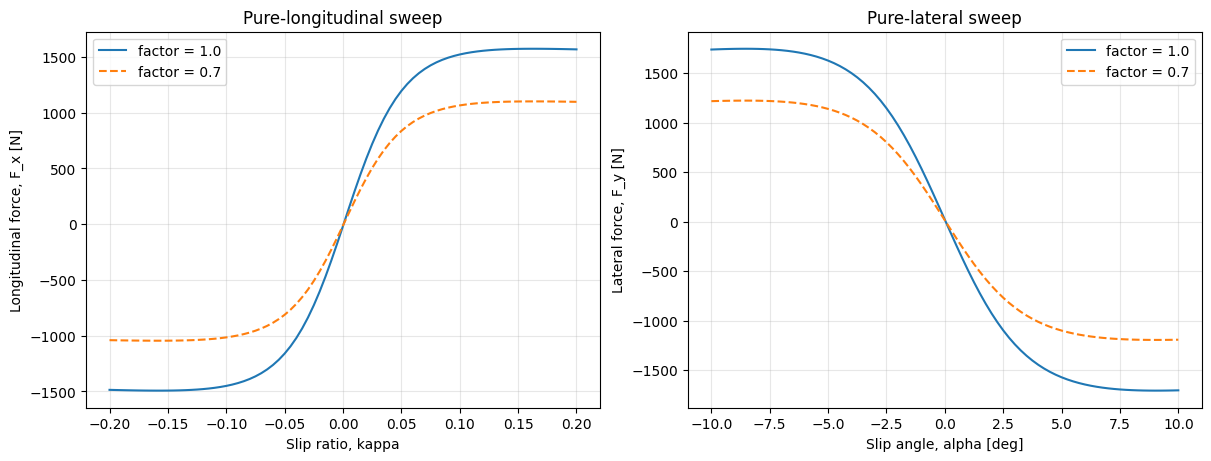

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(slip_ratios, forces_raw[0], label="factor = 1.0")
axes[0].plot(slip_ratios, forces_corrected[0], "--", label="factor = 0.7")
axes[0].set(
    xlabel="Slip ratio, kappa",
    ylabel="Longitudinal force, F_x [N]",
    title="Pure-longitudinal sweep",
)

axes[1].plot(slip_angles_deg, forces_raw[1], label="factor = 1.0")
axes[1].plot(slip_angles_deg, forces_corrected[1], "--", label="factor = 0.7")
axes[1].set(
    xlabel="Slip angle, alpha [deg]",
    ylabel="Lateral force, F_y [N]",
    title="Pure-lateral sweep",
)

for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()

plt.show()

The dashed curves are exactly 70% of the uncorrected force curves. Vehicle simulations use the same factors stored on the front and rear tire objects.

## 5. Clean up the fastest-lap registry

In [6]:
fastest_lap.delete_tire(tire_name)
for vehicle_name in vehicle_specs:
    fastest_lap.delete_variable(vehicle_name)
temporary_directory.cleanup()
print("Example variables and temporary XML files removed.")

Example variables and temporary XML files removed.
